# Assignment 1 - Particle filter

- **Topic:** Designing a particle filter to estimate the position using magnetic field information
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:**  28-02-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment1_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your groupnumber


## Instructions
**Installation:** The implementation is tested with python 3.9.12 and packages including
-   numpy version: 1.26.4
-   scipy version: 1.13.0
-   matplotlib version: 3.5.1


Other (not too old or new) versions will probably also work.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.



In [ ]:
groupNumber = 30

STUDENT_1_NAME = "Josephine King"
STUDENT_1_STUDENT_NUMBER = "6250513"

STUDENT_2_NAME = "Joost Jaspers"
STUDENT_2_STUDENT_NUMBER = "5372925"

# raise NotImplementedError()

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent. The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times N}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times N}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the particle filter you DO NOT need this dictionary.

In [59]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

''' load in the data'''
(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeParticleFilterAssignment(groupNumber % 29)


Below, a function is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. 

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times N}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{N}$.

This function should output three subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. In the middle the magnetic field measurements are plotted with  the ground truth positions on top of the magnetic field map. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

PLOT 1:

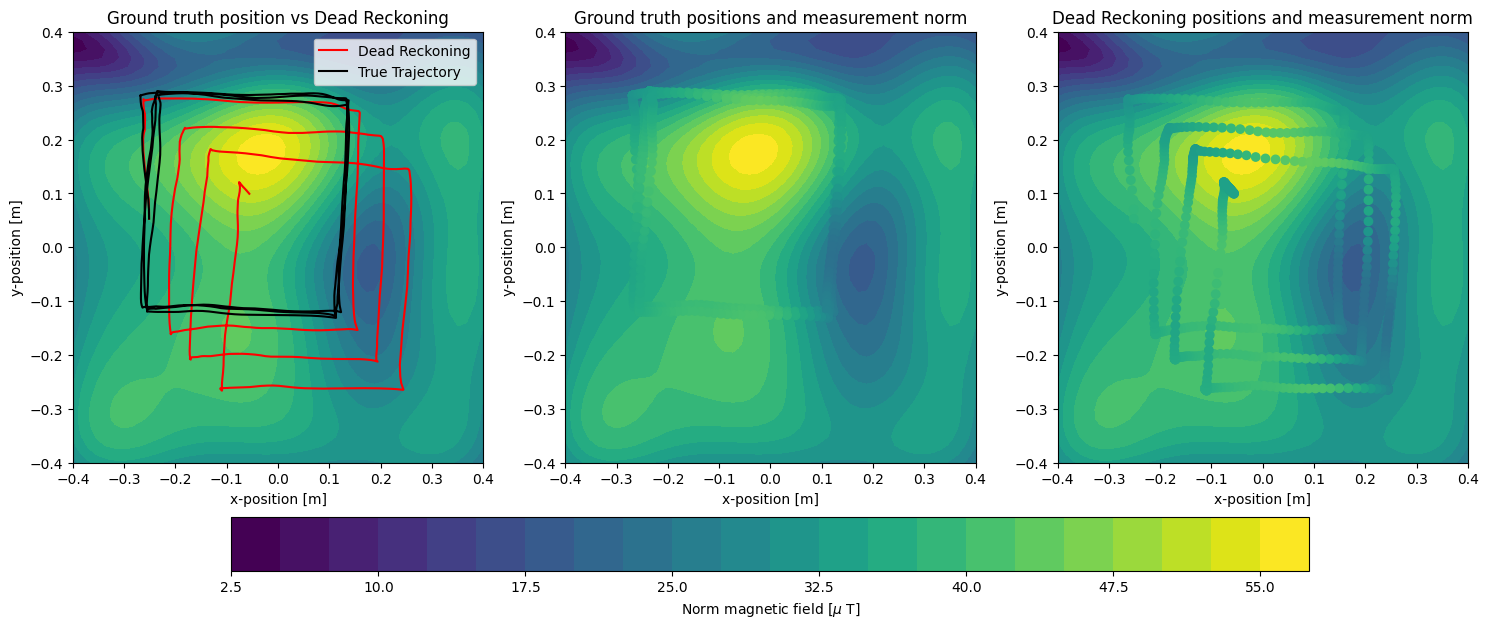

In [60]:
# Initialize variables 
N = deltaMagnetometerPositions.shape[1]
deadReckoning = np.zeros((3, N+1))
magneticFieldNorm = np.zeros((1, N))

# Loop through all the measurements to calculate the deadReckoning positions an magneticFieldNorm values
deadReckoning[:,0] = magnetometerInitialPosition.flatten()
for i in range(0,N):
    delta = deltaMagnetometerPositions[:,i]
    deadReckoning[:,i+1] = deadReckoning[:,i] + delta
    magneticFieldNorm[:,i] = np.linalg.norm(magnetometerMeasurements[:,i])

# Remove the initial position
deadReckoning = deadReckoning[:,1:N+1]

# Make plots
helper.makeInitialPositionPlots(deadReckoning, magneticFieldNorm, modelParameters)


### Discuss

Comment below on the three plots. 
- 	Does the dynamic model provide accurate enough information about the agent’s position? What will happen to the position of the agent if it moves for longer periods of time?

No, the dynamic model does not provide accurate enough information about the agent's position. As can be seen on the left plot, the dead reckoning position estimation accumulates error over time, causing the estimation to drift from the true position when simulated for longer periods.

- Based on the magnetic field map shown in the background, explain why or why not the magnetic field is a good source of information for position estimation. 

We can compare the magnetometer measurement with expected magnetic field based on the agent's estimated position. This could be a good source of information to correct for the drift that we see with dead reckoning. In the middle plot, we can see that the magnetometer measurements align very well with the magnetic field for the true positions. 

- Explain why the measurements do or do not agree with the magnetic field map (for the middle and the right plots).

In the middle plot, which plots the magnetometer measurements at the true agent positions, we can see that the measurements align quite well with the map. The small discrepancies that we see could be attributed to some noise, either in the map or in the measurements. In the right plot, the magnetometer measurements do not align with the map. This is because the dead reckoning estimation drifts from the true position over time. As a result, the magnetometer measurement does not match up with the measurement that we would expect based on the estimated position.


### Particle Filter Implementation

One way to reduce the positional drift observed in the figure above, is to use magnetometer measurements. To this end, you will design a particle filter. Your task is to fill in the following three functions.

#### Task
Fill in the `dynamicUpdate()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [61]:

def dynamicUpdate(particlePositions, 
                  deltaPosition,
                  processCovariance,
                  Nparticles):
    ''' Dynamic update '''

    # Loop through all the particles
    for i in range(0, Nparticles):
        # Randomly sample noise from the Gaussian distribution
        noise = np.random.multivariate_normal(np.zeros((3,)), processCovariance)
        # Update the particle position
        particlePositions[:,i] += deltaPosition + noise

    return particlePositions


#### Discuss

Comment on the role of the function of the dynamicUpdate in the particle filter

dynamicUpdate propagates all of the particles positions to the next time step based on the dynamic model. It does so by sampling from the probability distribution $p(p_t | p_{t-1})$. This is a Gaussian PDF (due to the WGN) which has mean of $p_{t-1} + \Delta p_{t}$ and a covariance of $Q$.

#### Task

Fill in the `measurementUpdate()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times N} $. The output should be a matrix $\in \mathbb{R}^{3 \times N}$ magnetic field predictions for every input location.

In [62]:
def measurementUpdate(particlePositions, 
                      particleWeights,
                      magnetometerMeasurement,
                      measurementCovariance,
                      Nparticles,
                      modelParameters):
    ''' Measurement update '''

    # Get the magnetic field predictions for the particles from the magnetic field map
    predictionsMagneticFieldParticles = GP.makeMagneticFieldPrediction(particlePositions, modelParameters)
    # Loop through all the particles
    for i in range(0, Nparticles):
        # Calculate the difference between the measurement and the prediction
        diff = np.reshape(magnetometerMeasurement - predictionsMagneticFieldParticles[:,i], (3,1))
        # Calculate p_y_given_x from the Gaussian distribution
        p_y_given_x = np.exp(-0.5*np.transpose(diff)@np.linalg.inv(measurementCovariance)@diff)
        # Update the particle weight
        particleWeights[i] = p_y_given_x*particleWeights[i]

    # Normalize the weights
    sumWeights = np.sum(particleWeights)
    for i in range(0, Nparticles):
        particleWeights[i] = particleWeights[i]/sumWeights

    return particlePositions, particleWeights


#### Discuss
Comment on the role of the function of the measurementUpdate in the particle filter

The measurement update evaluates how likely the measurement is for each particle position. Based on this likelihood, it assigns each particle with a weight, where a higher weight means that particle is more likely for the given measurement. Then the weights for all the particles are normalized. 

#### Task

Fill in the remainder of the `particleFilter()` function. 


In [63]:
def particleFilter(particlePositions, 
                   deltaPosition, 
                   magnetometerMeasurement, 
                   processCovariance, 
                   measurementCovariance, 
                   Nparticles,
                   modelParameters):
    ''' Estimates position based on a known map'''

    particleWeights = (1/Nparticles)*np.ones((Nparticles, 1))

    if modelParameters['NtimeStepPF'] > 0:
        ''' Dynamic update '''
        particlePositions = dynamicUpdate(particlePositions, 
                                          deltaPosition, 
                                          processCovariance, 
                                          Nparticles)  


    ''' Measurement update '''
    (particlePositions, 
        particleWeights) = measurementUpdate(particlePositions, 
                                             particleWeights,
                                             magnetometerMeasurement, 
                                             measurementCovariance, 
                                             Nparticles,
                                             modelParameters)

    ''' Resampling '''    
    if np.sum(particleWeights) > 1e-12:
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)
        particlePositions = particlePositions[:, indices]
    else:
        print('Degenerate particles: All the weights are close to zero !!!')
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)

    meanPosition = np.mean(particlePositions, 1)
    max_index = np.argmax(particleWeights)
    maxPosition = particlePositions[:,max_index]

    return particlePositions, meanPosition, maxPosition


#### Discuss

Comment on the role of the function of the systematicResample in the particle filter

systematicResample randomly samples the particleWeights according to how likely they are. So if a weight is higher, it is more likely to be sampled. The function then returns the indices of the particles it has selected, which are then used to resample the particle positions. The effect is to eliminate low-weight particles and duplicate high-weight particles.

#### Task 4

Choose a suitable amount of particles, an initial position covariance, a suitable motion covariance and a suitable measurement covariance.

You could start with the following parameters
- `initalPositionCovariance` = np.eye(3)*0
- `Nparticles` = 100
- `processCovariance` = np.eye(3)*0.001**2
- `measurementCovariance` = np.eye(3)*1.5**2

To get better results, you might have to tune these. 

In [64]:
''' Number of particles used in the particle filter '''
Nparticles = 100


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001**2
measurementCovariance = np.eye(3)*1.5**2


''' Initialize particle positions '''
particlePositions = np.zeros((3, Nparticles))
# Draw from a normal distribution with mean magnetometerInitialPosition and covariance initalPositionCovariance
for i in range(1,Nparticles):
    particlePositions[:,i] = np.random.multivariate_normal(magnetometerInitialPosition.flatten(), initalPositionCovariance)


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
bestParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
meanParticlePosition[:,0] = magnetometerInitialPosition.squeeze()
bestParticlePosition[:,0] = magnetometerInitialPosition.squeeze()


''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


### Visualize the output

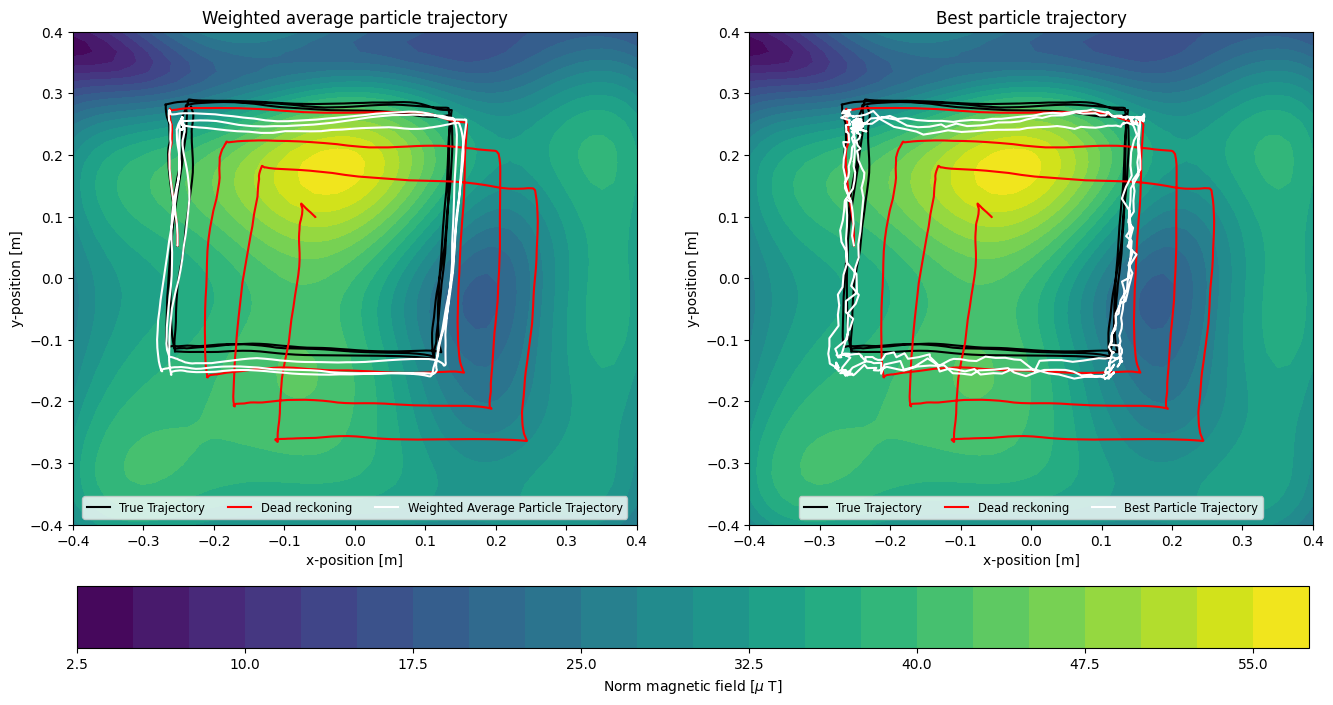

In [65]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Elaborate on the two plots.
- Does the particle filter improve the position estimates?

Yes, the particle filter improves the position estimates. There is no longer the large amount of drift that we saw with the dead reckoning state estimation. 

- Are the weighted average particle trajectory and the best particle trajectory the same or different? Why is that the case?

The weighted average trajectory looks quite different from the best particle trajectory. The weighted average is much smoother, because it doesn't change much between timesteps. The best particle trajectory on the other hand is much more jagged, because the best particle can completely change between time steps, putting it very far away from the previous best particle. This could happen especially if we have a few particles with very similar weights, then they might take turns being the best particle as their weights slightly change at each time step, causing the "best" particle trajectory to jump around.  


#### Task

Play around with different parameters. Comment on what happens if we choose lower or higher values for
- `initalPositionCovariance`? 

If we choose a larger value for the initialPositionCovariance (e.g. $0.1I$), the particle filter estimate is quite bad. This is because it is more uncertain of its initial position, meaning that at the start we have a wide spread of particles, all with equal weights. It can therefore be detrimental to choose a large initialPositionCovariance if you are very certain of your initial position, as we are in this case. However, we found that even with a high initialPositionCovariance, we could still get the particle filter to converge to a good estimate by increasing the number of particles.

- `Nparticles`? 

If the different covariances are tuned well, especially the initialPositionCovariance, not many particles are needed to converge to the right path. With these parameters, the particle filter performed well with at least 20 particles. Adding more particles improved the result, but not drastically. At a certain point, adding more particles gave diminishing returns, because the simulation took much longer to run without improving the result very much. However, with higher covariances (more noise), we found that we needed more particles to see good results. 

- `processCovariance`? 

If we increase the process covariance, the dynamic model is trusted less, meaning the magnetometer is trusted more. As a result, the estimated trajectory is based more on the information gathered from the magnetometer. This causes the estimated trajectory to diverge from the true trajectory a bit more on the top and the bottom of the square, where there is the most misalignment between the magnetometer measurements and the magnetic field map. Additionally, a higher process covariance means a larger spread of particles, which results in a less smooth trajectory, especially for the "best particle" trajectory. When we decrease the process covariance, we see the opposite effect, where the dynamic model is trusted more. As a result, we see more drift over time, similar to the dead reckoning estimation. But, the spread of particles is smaller, resulting in a smoother trajectory. 

- `measurementCovariance`? 

When we increase the measurement covariance, we trust the measurement less, meaning that we rely more on the dynamic model and see some drift over time. Additionally, $p(y|x)$ will have a larger spread, resulting in a "flatter" distribution where the probabilities of different measurements are more similar. As a result, the particles will have similar weights, causing the best particle trajectory to bounce around a lot while the average particle trajectory is pretty smooth. When we lower the measurement covariance, the measurement is trusted more, resulting in less drift but more error at the top and bottom of the square, as we mentioned earlier. Additionally, a smaller covariance results in a more compact distribution of particles, meaning that the bestParticle trajectory is pretty smooth. If the measurement covariance is too small, however, all of the particle weights are close to 0 because the distribution is very "sharp", and basically has 0 probability except in a very narrow range of locations. As a result, we get degenerate particles after the measurement update, and need to rely more on the dynamic model. 


In [67]:
''' Number of particles used in the particle filter '''
Nparticles = 100


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001**2
measurementCovariance = np.eye(3)*1.5**2


''' Initialize particle positions '''
particlePositions = np.zeros((3, Nparticles))
# Draw from a normal distribution with mean magnetometerInitialPosition and covariance initalPositionCovariance
for i in range(1,Nparticles):
    particlePositions[:,i] = np.random.multivariate_normal(magnetometerInitialPosition.flatten(), initalPositionCovariance)


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
bestParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
meanParticlePosition[:,0] = magnetometerInitialPosition.squeeze()
bestParticlePosition[:,0] = magnetometerInitialPosition.squeeze()

''' Initialize and run the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


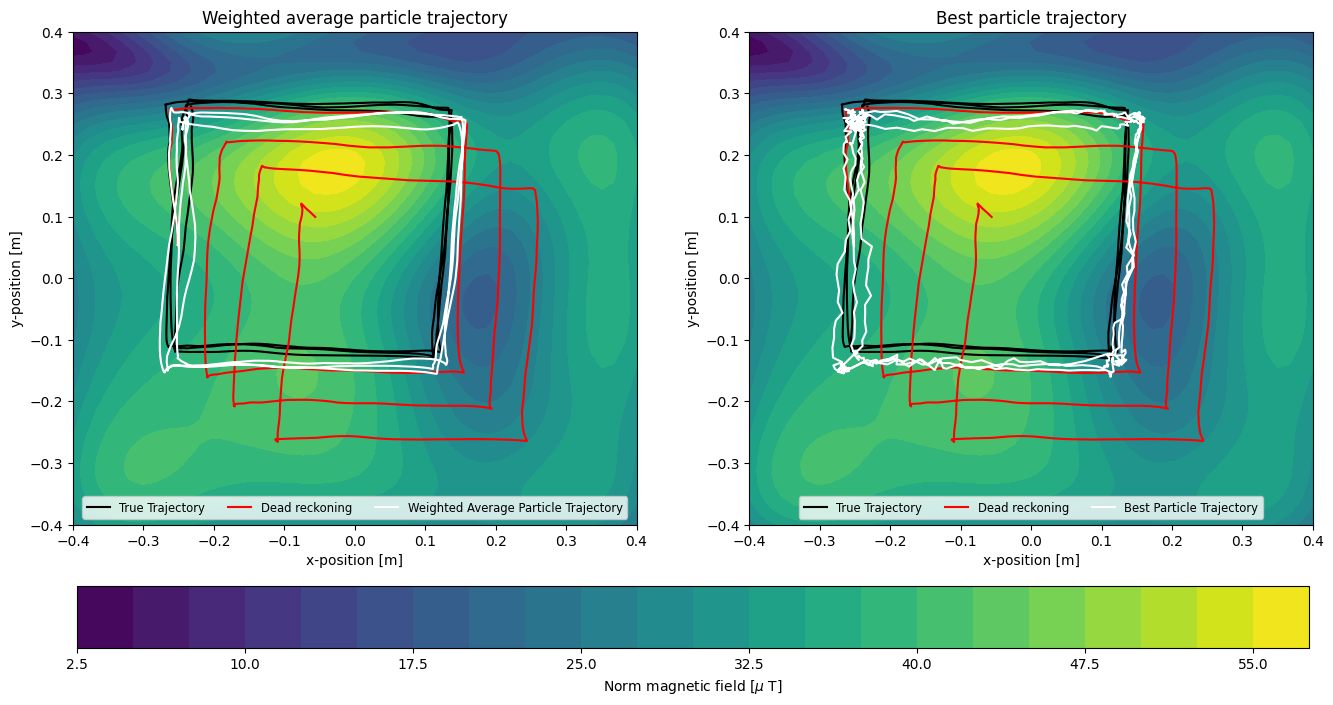

In [68]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Comment on the reason for choosing a particle filter for this estimation problem.

For this estimation problem, we have a nonlinear measurement model, which means that we cannot use a traditional Kalman filter. We could use an extended Kalman filter, which linearizes around the current estimate, but this linear approximation may not be very good for a highly nonlinear function or large time steps. In such cases, it can be better to use a particle filter, which allows for the use of a nonlinear measurement model without linearizing. With enough particles, we could get close to optimality.